<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Forecasting</p>

<p style="text-align: center;"> Course code: 203238431A </p>

<p style="text-align: center;"> Group: 02 </p>

<p style="text-align: center;"> Phase 3 Time Series Filtering and Frequency Domain
Transformations </p>

<p style="text-align: center;">  Presented by: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: BRAYAN ANDRU MONTENEGRO EMBUS </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, March 2026</p>

In [17]:
%pip install pykalman
%pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 170.2 kB/s eta 0:00:0000:0100:06


In [20]:
import sys
print(sys.executable)

/usr/bin/python3


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sktime.libs.pykalman import KalmanFilter

print('pykalman', __import__('pykalman').__version__)


pykalman 0.11.2


## Exercise 1: Kalman filter implementation and convergence analysis

### Data
For this exercise we will be using the provided datasset called "Appendix 1 - xy_motion_kalman_filter_example.csv" this data set has 205 rows and we asume that the columns refer to the x ans y position of an object due to the lack of headers in the CSV file provided.

To create the state vector, we asume a constant velocity asuming a random trajectory

In [ ]:
# ── Loading the CSV file ──────────────────────────────────────────
# The file does not have headers so we asume the following: first column = x, second column = y
#  We will be using the file loaded in the GitHub repository so we won't have troubles
#  when we want to rerun the code
CSV_Path = 'https://raw.githubusercontent.com/Jero2110/Forecasting_Phase_3/refs/heads/main/analysis/data/Appendix%201%20-%20xy_motion_kalman_filter_example.csv'

df = pd.read_csv(CSV_Path, header=None, names=['x', 'y'])

print(f'Filas: {len(df)}  |  Columnas: {list(df.columns)}')
print()
print('Primeras 5 filas:')
display(df.head())
print()
print('Estadísticas descriptivas:')
display(df.describe().round(2))


Filas: 205  |  Columnas: ['x', 'y']

Primeras 5 filas:


,x,y
0,2.35,1.45
1,3.55,1.80
2,3.00,2.90
3,2.65,4.20
4,2.95,5.15



Estadísticas descriptivas:


,x,y
count,205.00,205.00
mean,29.23,16.10
std,13.06,6.61
min,2.35,1.45
25%,20.20,10.95
50%,32.35,16.75
75%,39.75,21.55
max,47.30,26.60


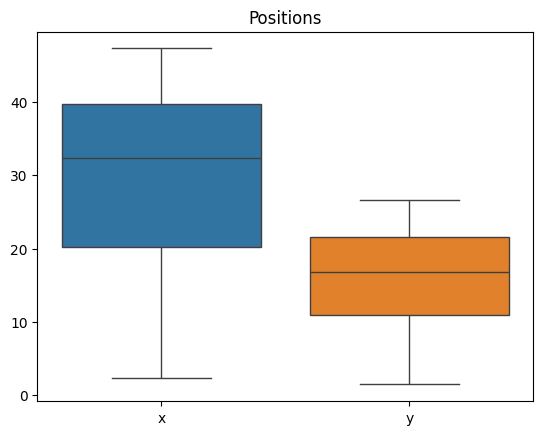

In [ ]:
# We create a boxplot to find possible outliers in the data
sns.boxplot(data=df)
plt.title('Positions')
plt.show()

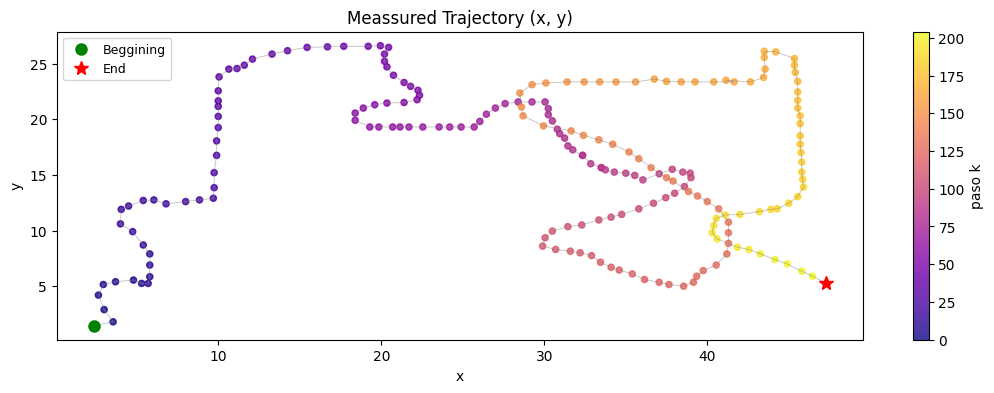

In [35]:
# ── Visual exploration of the trajectory ───────────────────────
fig, axes = plt.subplots(figsize=(13, 4))

# Scatter plot
sc = axes.scatter(df['x'], df['y'], c=range(len(df)), cmap='plasma',
                s=20, alpha=0.8)
axes.plot(df['x'], df['y'], '-', color='gray', lw=0.6, alpha=0.5)
axes.plot(df['x'].iloc[0],  df['y'].iloc[0],  'go', ms=8, label='Beggining')
axes.plot(df['x'].iloc[-1], df['y'].iloc[-1], 'r*', ms=10, label='End')
plt.colorbar(sc, ax=axes, label='paso k')
axes.set_title('Meassured Trajectory (x, y)')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.legend(fontsize=9)


In [27]:
df.isnull().sum()

,0
x,0
y,0


As we can see, the provided dataset does not appear to contain any null values ​​that could interfere with the modeling process. Also, we can see that there are no outlyers in the data with the boxplot. However we can see that the movement doesn't have a defined trajectory, in fact, we can see at some point that the object start to return in his path several times.

---
### Kalman Filter theory


The Kalman filter addresses the general problem of trying to estimate the state of a discrete-time controlled process where we have uncertain information, and we can make an educated guess about what the system is going to do next. For this reason, Kalman filters are ideal for systems which are continuously changing.

### **System Modelling**

$$x_k = Ax_{k-1} + Bu_k + w_{k}, \quad w_k \sim \mathcal{N}(0, Q)$$
$$z_k = Hx_k + v_k, \quad v_k \sim \mathcal{N}(0, R)$$

Where:

* $x_k$: It's the state value or vector we are trying to estimate
* $x_{k-1}$: It's the previous value we estimate
* $A$: It's the $nxn$ matrix that relates the state at the previous time step $k-1$ to the state at the current step $k$, in the absence of either a driving function or process noise. 
* $B$: The $nx1$ matrix relates the optional control input ($u_k$) to the state x.
* $u_k$: Represents the control signal
* $w_{k}$: Represents the process noise.
* $Q$: Process noise covariance. 
* $z_k$: Meassurment at the time.
* $H$: The matrix $mxn$ relates the state to the measurement
* $v_{k}$: Represents the measurement noise
* $R$: Meassurment noise covariance.


### **Kalman Filter Cycle**

| Step | Equation | Description |
|------|----------|-------------|
| Prediction (state vector) | $\hat{x}^-_k = A\hat{x}_{k-1} + Bu_k$ | Initial estimate  |
| Prediction (covariance matrix) | $P^-_k = AP_{k-1}A^T + Q$ | Increase uncertainty  |
| Kalman Gain | $K_k = P^-_kH^T(HP^-_kH^T + R)^{-1}$ | Measurement weight |
| Updating (state vector) | $\hat{x}_k = \hat{x}^-_k + K_k(z_k - H\hat{x}^-_k)$ | Merge prediction and measurement |
| Updating (covariance matrix) | $P_k = (1 - K_kH)\,P^-_k$ | Reduce uncertainty |



### Case of study

In this case, as we are trying to estimate the position of an object with a random trajectory. we need to build our model in a 2D scenario as it follows:

**State Vector** (4 dimentions):
$$\mathbf{x}_k = \begin{bmatrix} x \\ y \\ v_x \\ v_y \end{bmatrix}$$

**Transition equation** (Constant velocity model, $\Delta t = 1$):
$$\mathbf{x}_k = A \, \mathbf{x}_{k-1} + \mathbf{w}_k, \quad \mathbf{w}_k \sim \mathcal{N}(0, Q)$$
$$F = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

**Observation equation** (We only meassure x and y):
$$\mathbf{z}_k = H \, \mathbf{x}_k + \mathbf{v}_k, \quad \mathbf{v}_k \sim \mathcal{N}(0, R)$$
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

In [36]:
# ── Vectorization of observations ──────────────────────────────────
observations = df[['x', 'y']].to_numpy() 

n_steps, n_obs = observations.shape
n_state        = 4   # [x, y, vx, vy]
dt             = 1.0 # delta time between steps

print(f'Observations shape = {observations.shape}')
print(f'  → {n_steps} steps, {n_obs} observation dimensions')
print(f'  → State vector: {n_state} dimensions [x, y, vx, vy]')

Observations shape = (205, 2)
  → 205 steps, 2 observation dimensions
  → State vector: 4 dimensions [x, y, vx, vy]


---
### Initialization — State and covariance vectors

Before we run the filter, we must define an initial value for:

- **$\hat{x}_0$** : Initial estimate of the state (It can ve guessed).
- **$P_0$** : Initial covariance (uncertainty) about that guess.
  - If $P_0$ is big → "We don't really know much about it".
  - If $P_0$ is small → "We have confidence over our estimation".

In this case, we use an small value for $P_0$ because we have acces to the real information and we can easly define a number that is near to the real meassured value, however, for the velocity, that we do not know, we will be using a larger number (10)

In [57]:
# ── Definition of the system matrices ───────────────────────────

# A — State transition matrix (constant speed model)
# x_k = x_{k-1} + vx*dt
# y_k = y_{k-1} + vy*dt
# vx y vy are constant (without acceletarion)
A = np.array([
    [1, 0, dt, 0 ],
    [0, 1, 0,  dt],
    [0, 0, 1,  0 ],
    [0, 0, 0,  1 ]
])

# H — Observation matrix (We only meassure x and y, without velocity)
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# mu_0 — Initial state: first position, initial velocity = 0
mu_0 = np.array([5, 2, 0.0, 0.0])

# P_0 — Initial covariance (high uncertainty in velocity)
P_0 = np.diag([2.0, 2.0, 10.0, 10.0])

print('State transition matrix A:')
print(A)
print('\nObservation matrix H:')
print(H)
print('\nInitial state mu_0:', mu_0)
print('Initial covariance P_0 (diagonal):', np.diag(P_0))

State transition matrix A:
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

Observation matrix H:
[[1 0 0 0]
 [0 1 0 0]]

Initial state mu_0: [5. 2. 0. 0.]
Initial covariance P_0 (diagonal): [ 2.  2. 10. 10.]


In [47]:
# ── Initialize KalmanFilter ──────────────────────────────────────────

# Q — Covariance of process noise (model uncertainty)
Q = np.eye(n_state) * 0.1

# R — Measurement noise covariance (sensor confidence)
R = np.eye(n_obs) * 1.0

kf = KalmanFilter(
    transition_matrices    = A,    # F: System dymanic
    observation_matrices   = H,    # H: Observations
    transition_covariance  = Q,    # Q: Model noise
    observation_covariance = R,    # R: Meassurement noise
    initial_state_mean     = mu_0, # x̂₀
    initial_state_covariance = P_0 # P₀
)

print('KalmanFilter correctly initialized')
print(f'   State dimention      : {n_state}  [x, y, vx, vy]')
print(f'   Meassurement dimention  : {n_obs}   [x, y]')


KalmanFilter correctly initialized
   State dimention      : 4  [x, y, vx, vy]
   Meassurement dimention  : 2   [x, y]


---
### Prediction step

$$\hat{x}^-_k = A\hat{x}_{k-1} + Bu_k$$

$$P^-_k = AP_{k-1}A^T + Q$$

Covariance grows because the world might have change over steps by the noise of the process $Q$.

In [56]:
def predict(A, x, P, Q):
    """
    Predicts the state and the covaraince one step ahead.

    Parameters
    ----------
    x : array (1 x n)  — actual estimation of the state
    P : matrix (n x n) — actual covariance
    A : matrix (n x n) 
    Q : matrix  — model noise

    Returns
    -------
    x_pred, P_pred
    """
    x_pred = np.dot(A, x)
    P_pred = np.dot(np.dot(A, P), A.T) + Q    
    return x_pred, P_pred


# --- For the previous values defined ---
x_pred, P_pred = predict(A, mu_0, P_0, Q)

print(f'Predicción:')
print(f'  x̂⁻₁ = {x_pred}')
print(f'  P⁻₁ =\n {P_pred}')

Predicción:
  x̂⁻₁ = [5. 2. 0. 0.]
  P⁻₁ =
 [[12.1  0.  10.   0. ]
 [ 0.  12.1  0.  10. ]
 [10.   0.  10.1  0. ]
 [ 0.  10.   0.  10.1]]


---
### Kalman Gain

$$K_k = P^-_kH^T(HP^-_kH^T + R)^{-1}$$

- $K \to 1$ → We trust the meassure and have high uncertainty about the model.
- $K \to 0$ → We trust the model and have high uncertainty about the meassure.

In [54]:
def kalman_gain(P_pred, R, H):
    """
    
    Calculate the scalar Kalman gain.

    Parameters
    ----------
    P_pred : matrix (n x n)  — Predicted covariance
    R : matrix (n x n) — noise covariance
    H : matrix (n x n) — Observation matrix

    Returns
    -------
    Kalman Gain

    """

    S = (np.dot(H, np.dot(P_pred, H.T))+R)
    k_gain = np.dot(np.dot(P_pred, H.T), np.linalg.inv(S))

    return k_gain


K = kalman_gain(P_pred, R, H)
print(f'Kalman gain K₁ =\n {K}')
print()


Kalman gain K₁ =
 [[0.92366412 0.        ]
 [0.         0.92366412]
 [0.76335878 0.        ]
 [0.         0.76335878]]



---
## Updating the meassurement

$$\hat{x}_k = \hat{x}^-_k + K_k\,(z_k - \hat{x}^-_k)$$
$$P_k = (1 - K_k)\,P^-_k$$

- The term $(z_k - \hat{x}^-_k)$ is often called innovation or residue.
- For the updated covariance $P_k < P^-_k$ — we espect that the uncertainty decreases after the meassurement.

In [70]:
def update(x_pred, P_pred, z, K, H):
    """
    Updates the state and the Covariance with the new meassurement z.

    Parameters
    ----------
    x_pred : array (1 x n)  — 
    P_pred : array (n x n)  — Predicted covariance
    z : float  — noise covariance
    K : float  — Kalman Gain
    
    Returns
    -------
    x_upd, P_upd, innovation
    """
    innovation = z - np.dot(H, x_pred)                  # residue
    x_upd = x_pred + np.dot(K, innovation)              # updated state
    I = np.eye(4)
    P_upd = np.dot((I - np.dot(K, H)), P_pred)          # updated covariance
    return x_upd, P_upd, innovation



z1 = observations[0]  # First real meassurement

x_upd, P_upd, innov = update(x_pred, P_pred, z1, K, H)

print(f'Meassurement z₁ = {z1}')
print(f'Innovation = {innov}')
print(f'Updated state x̂₁ = {x_upd}')
print(f'Updated covariance P₁ =\n {P_upd}')

Meassurement z₁ = [2.35 1.45]
Innovation = [-2.65 -0.55]
Updated state x̂₁ = [ 2.55229008  1.49198473 -2.02290076 -0.41984733]
Updated covariance P₁ =
 [[0.92366412 0.         0.76335878 0.        ]
 [0.         0.92366412 0.         0.76335878]
 [0.76335878 0.         2.46641221 0.        ]
 [0.         0.76335878 0.         2.46641221]]


---
### Convergence Analysis: Q < R  vs  Q > R  

| Case | Behavior |
|-----------|----------------|
| **Q < R** | P converges rapidly to a low value; K stabilizes small; smooth estimate |
| **Q > R** | P converges to a high value; K remains high; estimate follows measurements |